# 03 - Track A: Direct Price Regression Models

This notebook implements direct price prediction models using Linear Regression, Random Forest, and XGBoost with time-based evaluation.

## Configurati

In [1]:
# Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib

# Import our utilities
import sys
sys.path.append('.')
from utils_splits import create_time_split, validate_no_leakage

# Set random seed for reproducibility
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "features"
RESULTS_DIR = PROJECT_ROOT / "results"
CODE_DIR = PROJECT_ROOT / "code"

# Configuration parameters
TEST_START_DATE = "2024-07-01"

print(f"Features directory: {FEATURES_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Test start date: {TEST_START_DATE}")


Features directory: /Users/antoniolavenia/Desktop/Data Science/features
Results directory: /Users/antoniolavenia/Desktop/Data Science/results
Test start date: 2024-07-01


## Load Training Data


In [2]:
# Load training table
print("Loading training data...")
training_table = pd.read_parquet(FEATURES_DIR / 'training_table.parquet')

print(f"✅ Loaded training data:")
print(f"  Original shape: {training_table.shape}")

# Sample data for faster training (reduce to 50k rows)
if len(training_table) > 50000:
    print("Sampling data for faster training...")
    training_table = training_table.sample(n=50000, random_state=42)
    print(f"  Sampled shape: {training_table.shape}")

print(f"  Date range: {training_table['date'].min()} to {training_table['date'].max()}")
print(f"  Price range: €{training_table['price'].min():.2f} to €{training_table['price'].max():.2f}")

# Check for missing values
missing_counts = training_table.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    print(missing_counts[missing_counts > 0])
else:
    print(f"\n✅ No missing values in training data")


Loading training data...
✅ Loaded training data:
  Original shape: (1827000, 46)
Sampling data for faster training...
  Sampled shape: (50000, 46)
  Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
  Price range: €5.16 to €2608.57

⚠️  Missing values found:
temp_avg           50000
precip_mm          50000
humidity           50000
wind_speed         50000
neighbourhood      18030
migration_ratio     1912
dtype: int64


## Time-Based Train/Test Split


In [3]:
# Create time-based split
print("Creating time-based train/test split...")
train_df, test_df = create_time_split(training_table, TEST_START_DATE, 'date')

# Validate no leakage
validate_no_leakage(train_df, test_df, 'date')

# Print split summary
print(f"\n📊 Split Summary:")
print(f"  Train: {len(train_df)} samples ({len(train_df)/len(training_table):.1%})")
print(f"  Test: {len(test_df)} samples ({len(test_df)/len(training_table):.1%})")
print(f"  Train date range: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"  Test date range: {test_df['date'].min()} to {test_df['date'].max()}")

# Check price distributions
print(f"\n💰 Price Statistics:")
print(f"  Train - Mean: €{train_df['price'].mean():.2f}, Std: €{train_df['price'].std():.2f}")
print(f"  Test - Mean: €{test_df['price'].mean():.2f}, Std: €{test_df['price'].std():.2f}")


Creating time-based train/test split...
Train set: 44997 rows, dates 2020-01-01 00:00:00 to 2024-06-30 00:00:00
Test set: 5003 rows, dates 2024-07-01 00:00:00 to 2024-12-31 00:00:00

📊 Split Summary:
  Train: 44997 samples (90.0%)
  Test: 5003 samples (10.0%)
  Train date range: 2020-01-01 00:00:00 to 2024-06-30 00:00:00
  Test date range: 2024-07-01 00:00:00 to 2024-12-31 00:00:00

💰 Price Statistics:
  Train - Mean: €145.94, Std: €147.94
  Test - Mean: €152.96, Std: €156.68


## Feature Engineering and Preprocessing


In [4]:
def prepare_features(df):
    """
    Prepare features for machine learning models.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with all features
        
    Returns:
    --------
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Target variable (price)
    feature_names : list
        List of feature names
    """
    # Select features for modeling
    feature_columns = [
        # Seasonality features
        'day_of_week', 'is_weekend', 'month', 'week_of_year', 'day_of_year',
        'is_holiday', 'is_holiday_window', 'is_peak_season', 'is_ferragosto',
        'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2',
        'is_spring', 'is_summer', 'is_autumn', 'is_winter',
        
        # Listing features
        'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
        'number_of_reviews', 'review_scores_rating', 'minimum_nights',
        'maximum_nights', 'availability_365',
        
        # Location features (if available)
        'latitude', 'longitude',
        
        # Weather features (stubbed)
        'temp_avg', 'precip_mm', 'humidity', 'wind_speed'
    ]
    
    # Filter to available columns
    available_features = [col for col in feature_columns if col in df.columns]
    print(f"Using {len(available_features)} features for modeling")
    
    # Create feature matrix
    X = df[available_features].copy()
    y = df['price'].copy()
    
    # Handle categorical features
    categorical_features = ['room_type', 'neighbourhood', 'neighbourhood_cleansed']
    categorical_features = [col for col in categorical_features if col in df.columns]
    
    if categorical_features:
        print(f"Categorical features: {categorical_features}")
        # For simplicity, we'll drop high-cardinality categoricals or encode them
        for col in categorical_features:
            if df[col].nunique() > 50:  # High cardinality
                print(f"  Dropping high-cardinality feature: {col} ({df[col].nunique()} unique values)")
                if col in X.columns:
                    X = X.drop(col, axis=1)
            else:
                # One-hot encode low-cardinality categoricals
                dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
                X = pd.concat([X, dummies], axis=1)
                print(f"  One-hot encoded: {col} -> {dummies.shape[1]} features")
    
    # Fill any remaining missing values
    X = X.fillna(0)
    
    return X, y, X.columns.tolist()

# Prepare features for train and test sets
print("Preparing features...")
X_train, y_train, feature_names = prepare_features(train_df)
X_test, y_test, _ = prepare_features(test_df)

print(f"\n✅ Feature preparation completed:")
print(f"  Train features: {X_train.shape}")
print(f"  Test features: {X_test.shape}")
print(f"  Feature names: {len(feature_names)}")

# Check for any remaining missing values
assert X_train.isnull().sum().sum() == 0, "Train features contain missing values"
assert X_test.isnull().sum().sum() == 0, "Test features contain missing values"
print("✅ No missing values in feature matrices")


Preparing features...
Using 30 features for modeling
Categorical features: ['room_type', 'neighbourhood', 'neighbourhood_cleansed']
  One-hot encoded: room_type -> 3 features
  Dropping high-cardinality feature: neighbourhood (229 unique values)
  Dropping high-cardinality feature: neighbourhood_cleansed (135 unique values)
Using 30 features for modeling
Categorical features: ['room_type', 'neighbourhood', 'neighbourhood_cleansed']
  One-hot encoded: room_type -> 3 features
  Dropping high-cardinality feature: neighbourhood (228 unique values)
  Dropping high-cardinality feature: neighbourhood_cleansed (135 unique values)

✅ Feature preparation completed:
  Train features: (44997, 33)
  Test features: (5003, 33)
  Feature names: 33
✅ No missing values in feature matrices


## Model Training and Evaluation


In [5]:
# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse')
}

# Hyperparameter search spaces (light search to keep runtime reasonable)
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

# Train and evaluate models
results = {}
best_model = None
best_score = float('inf')

print("Training models...")
for name, model in models.items():
    print(f"\n🔧 Training {name}...")
    
    # Hyperparameter tuning for tree-based models
    if name in param_grids:
        print(f"  Hyperparameter tuning...")
        search = RandomizedSearchCV(
            model, param_grids[name], 
            n_iter=10, cv=3, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error'
        )
        search.fit(X_train, y_train)
        model = search.best_estimator_
        print(f"  Best params: {search.best_params_}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'predictions': y_pred_test
    }
    
    print(f"  Train RMSE: €{train_rmse:.2f}, Test RMSE: €{test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.3f}, Test R²: {test_r2:.3f}")
    
    # Track best model
    if test_rmse < best_score:
        best_score = test_rmse
        best_model = model
        best_model_name = name

print(f"\n🏆 Best model: {best_model_name} (RMSE: €{best_score:.2f})")


Training models...

🔧 Training Linear Regression...
  Train RMSE: €124.56, Test RMSE: €129.44
  Train R²: 0.291, Test R²: 0.317

🔧 Training Random Forest...
  Hyperparameter tuning...
  Best params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}
  Train RMSE: €15.04, Test RMSE: €32.49
  Train R²: 0.990, Test R²: 0.957

🔧 Training XGBoost...
  Hyperparameter tuning...
  Best params: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
  Train RMSE: €12.20, Test RMSE: €33.70
  Train R²: 0.993, Test R²: 0.954

🏆 Best model: Random Forest (RMSE: €32.49)


## Save Results and Best Model


Saving results and models...
✅ Best model saved: /Users/antoniolavenia/Desktop/Data Science/code/best_price_model.pkl
✅ Metrics saved: /Users/antoniolavenia/Desktop/Data Science/results/metrics_summary.csv
✅ Individual model metrics saved


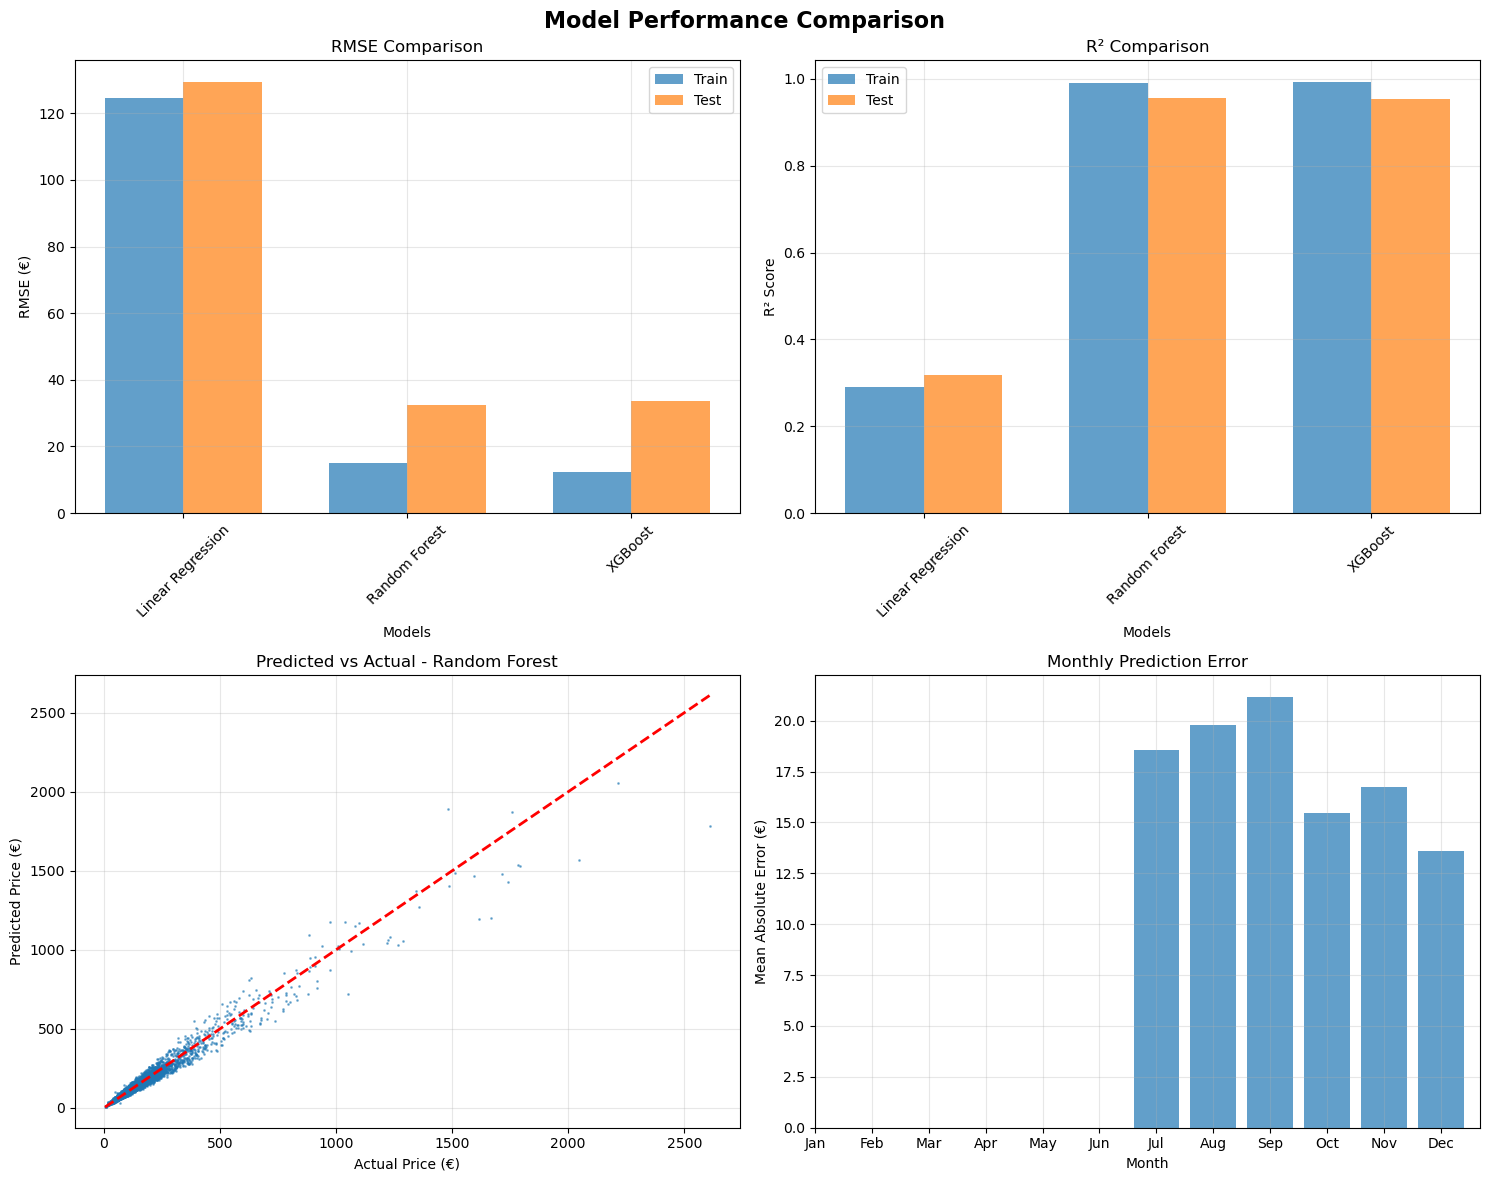

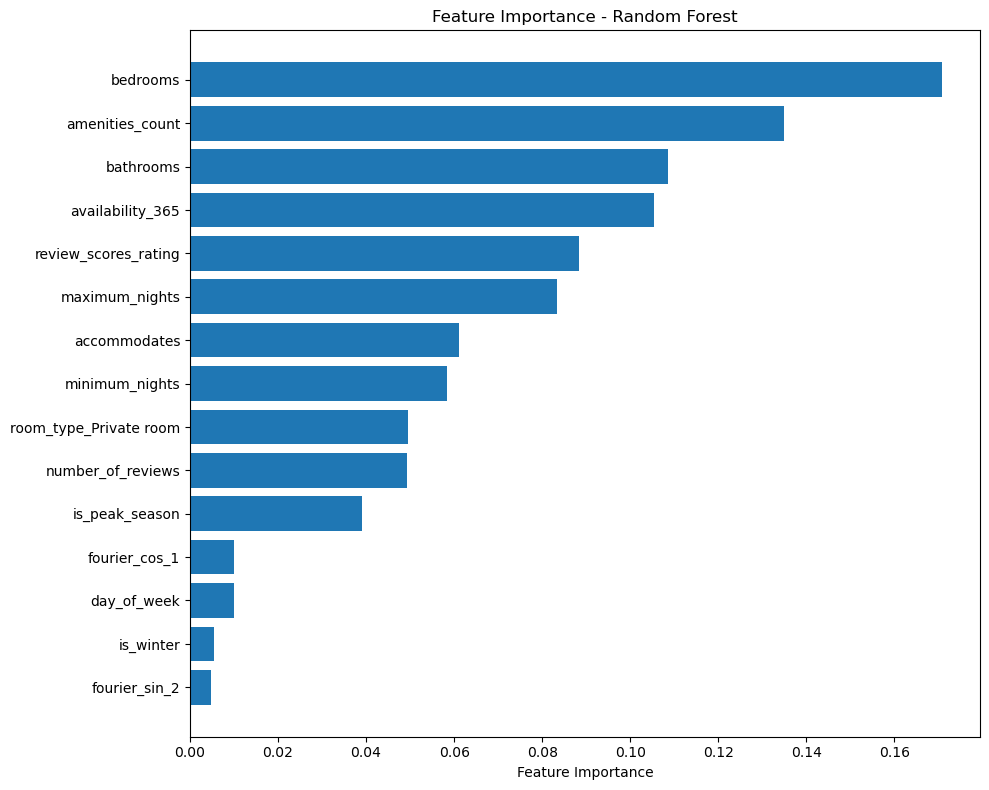


✅ Track A - Direct price regression completed!
🏆 Best model: Random Forest (RMSE: €32.49)
📊 Results saved to: /Users/antoniolavenia/Desktop/Data Science/results
🤖 Best model saved to: /Users/antoniolavenia/Desktop/Data Science/code/best_price_model.pkl


In [6]:
# Save results and create summary
print("Saving results and models...")

# Save best model
joblib.dump(best_model, CODE_DIR / 'best_price_model.pkl')
print(f"✅ Best model saved: {CODE_DIR / 'best_price_model.pkl'}")

# Create metrics summary
metrics_summary = []
for name, result in results.items():
    metrics_summary.append({
        'model': name,
        'train_rmse': result['train_rmse'],
        'test_rmse': result['test_rmse'],
        'train_mae': result['train_mae'],
        'test_mae': result['test_mae'],
        'train_r2': result['train_r2'],
        'test_r2': result['test_r2']
    })

metrics_df = pd.DataFrame(metrics_summary)
metrics_df.to_csv(RESULTS_DIR / 'metrics_summary.csv', index=False)
print(f"✅ Metrics saved: {RESULTS_DIR / 'metrics_summary.csv'}")

# Save individual model metrics
for name, result in results.items():
    model_metrics = {
        'model': name,
        'train_rmse': result['train_rmse'],
        'test_rmse': result['test_rmse'],
        'train_mae': result['train_mae'],
        'test_mae': result['test_mae'],
        'train_r2': result['train_r2'],
        'test_r2': result['test_r2']
    }
    
    import json
    with open(RESULTS_DIR / f'metrics_price_{name.lower().replace(" ", "_")}.json', 'w') as f:
        json.dump(model_metrics, f, indent=2)

print(f"✅ Individual model metrics saved")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. RMSE comparison
models = list(results.keys())
train_rmse = [results[m]['train_rmse'] for m in models]
test_rmse = [results[m]['test_rmse'] for m in models]

x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, train_rmse, width, label='Train', alpha=0.7)
axes[0, 0].bar(x + width/2, test_rmse, width, label='Test', alpha=0.7)
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('RMSE (€)')
axes[0, 0].set_title('RMSE Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. R² comparison
train_r2 = [results[m]['train_r2'] for m in models]
test_r2 = [results[m]['test_r2'] for m in models]

axes[0, 1].bar(x - width/2, train_r2, width, label='Train', alpha=0.7)
axes[0, 1].bar(x + width/2, test_r2, width, label='Test', alpha=0.7)
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Predicted vs Actual (best model)
best_predictions = results[best_model_name]['predictions']
axes[1, 0].scatter(y_test, best_predictions, alpha=0.5, s=1)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Price (€)')
axes[1, 0].set_ylabel('Predicted Price (€)')
axes[1, 0].set_title(f'Predicted vs Actual - {best_model_name}')
axes[1, 0].grid(True, alpha=0.3)

# 4. Monthly RMSE
test_df_with_pred = test_df.copy()
test_df_with_pred['predicted_price'] = best_predictions
test_df_with_pred['residual'] = test_df_with_pred['price'] - test_df_with_pred['predicted_price']
test_df_with_pred['abs_residual'] = np.abs(test_df_with_pred['residual'])

monthly_rmse = test_df_with_pred.groupby('month')['abs_residual'].mean()
axes[1, 1].bar(monthly_rmse.index, monthly_rmse.values, alpha=0.7)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Mean Absolute Error (€)')
axes[1, 1].set_title('Monthly Prediction Error')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_importance.head(15))), feature_importance.head(15)['importance'])
    plt.yticks(range(len(feature_importance.head(15))), feature_importance.head(15)['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'feature_importance_xgb.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"\n✅ Track A - Direct price regression completed!")
print(f"🏆 Best model: {best_model_name} (RMSE: €{best_score:.2f})")
print(f"📊 Results saved to: {RESULTS_DIR}")
print(f"🤖 Best model saved to: {CODE_DIR / 'best_price_model.pkl'}")
